In [20]:
from google.colab import drive
drive.mount("/content/drive")
dataset_folder = "/content/drive/MyDrive/datasets/dataset"
dataset_folder

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/datasets/dataset'

In [21]:
# TASK 1


import os

def print_tree(folder, indent=""):
    for item in os.listdir(folder):
        path = os.path.join(folder, item)
        # print(path)
        print(indent + "|-- " + item)
        for i in os.listdir(path):
            new_path = os.path.join(path, i)
            print(f"{(indent + "    |-- " + i):<22}  -->  {len(os.listdir(new_path))} images")
            

print("dataset/")
print_tree(dataset_folder)

dataset/
|-- validation
    |-- organic         -->  205 images
    |-- recyclable      -->  289 images
    |-- non_recyclable  -->  31 images
|-- train
    |-- recyclable      -->  1104 images
    |-- non_recyclable  -->  104 images
    |-- organic         -->  794 images


In [24]:
# TASK 2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    f"{dataset_folder}/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    f"{dataset_folder}/validation",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 2002 images belonging to 3 classes.
Found 525 images belonging to 3 classes.


In [25]:
# TASK 3

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(3,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1245s 20s/step - accuracy: 0.5939 - loss: 0.8929 - val_accuracy: 0.6476 - val_loss: 0.7855
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 289s 5s/step - accuracy: 0.6628 - loss: 0.7093 - val_accuracy: 0.6971 - val_loss: 0.7642
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 276s 4s/step - accuracy: 0.6723 - loss: 0.7129 - val_accuracy: 0.7181 - val_loss: 0.6891
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 335s 5s/step - accuracy: 0.6843 - loss: 0.6969 - val_accuracy: 0.6476 - val_loss: 0.7244
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 276s 4s/step - accuracy: 0.6803 - loss: 0.6656 - val_accuracy: 0.7124 - val_loss: 0.6794


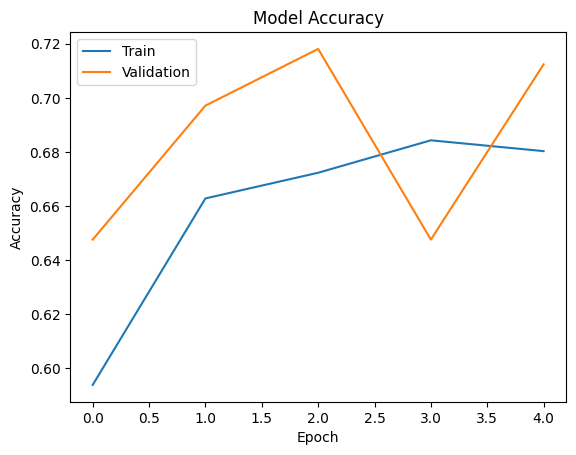

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

In [8]:
# TASK 4

from sklearn.metrics import confusion_matrix
import numpy as np

predictions = model.predict(val_data)

y_pred = np.argmax(predictions,axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true,y_pred)

print(cm)

17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
[[  0   5  26]
 [  0  45 160]
 [  0  70 219]]


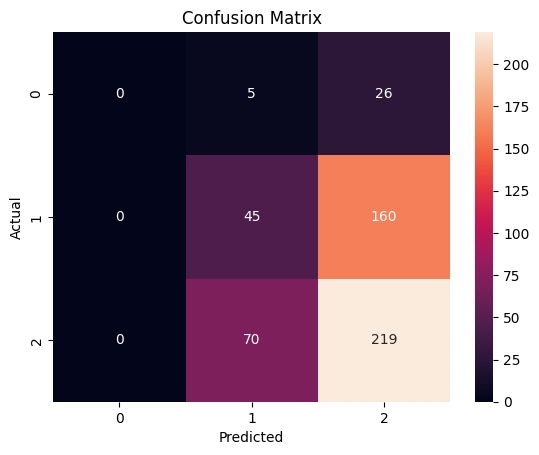

In [9]:
import seaborn as sns

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true,y_pred)
print("Accuracy:",acc)

Accuracy: 0.5028571428571429


In [47]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("/content/drive/MyDrive/datasets/images/paper_sample.png",target_size=(224,224))

img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)

classes = ["recyclable","organic","non_recyclable"]

print("Prediction:",classes[np.argmax(prediction)])
print("Prediction:",prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Prediction: non_recyclable
Prediction: [[0.3036318  0.30695367 0.3894145 ]]


In [16]:
# TASK 5

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
